In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams["figure.dpi"] = 100

# pd.set_option("display.max_columns", None)
# pd.set_option("display.max_rows", 100)

# Data inladen

In [2]:
df = pd.read_csv("../data/dataset_mood_smartphone.csv", index_col=0)
df["time"] = pd.to_datetime(df["time"])

In [133]:

print(f"Shape: {df.shape}")
print(f"Number of records: {len(df):,}")
print(f"Number of patients: {df['id'].nunique()}")
print(f"Number of variables: {df['variable'].nunique()}")
print(f"Time range: {df['time'].min()} to {df['time'].max()}")


Shape: (376912, 4)
Number of records: 376,912
Number of patients: 27
Number of variables: 19
Time range: 2014-02-17 07:00:52.197000 to 2014-06-09 00:00:00


In [13]:
print("Variables:")
print(sorted(df["variable"].unique()))
print(f"\nPatient IDs ({df['id'].nunique()}):")
print(sorted(df["id"].unique()))

Variables:
['activity', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call', 'circumplex.arousal', 'circumplex.valence', 'mood', 'screen', 'sms']

Patient IDs (27):
['AS14.01', 'AS14.02', 'AS14.03', 'AS14.05', 'AS14.06', 'AS14.07', 'AS14.08', 'AS14.09', 'AS14.12', 'AS14.13', 'AS14.14', 'AS14.15', 'AS14.16', 'AS14.17', 'AS14.19', 'AS14.20', 'AS14.23', 'AS14.24', 'AS14.25', 'AS14.26', 'AS14.27', 'AS14.28', 'AS14.29', 'AS14.30', 'AS14.31', 'AS14.32', 'AS14.33']


Alle variabelen van 1 persoon

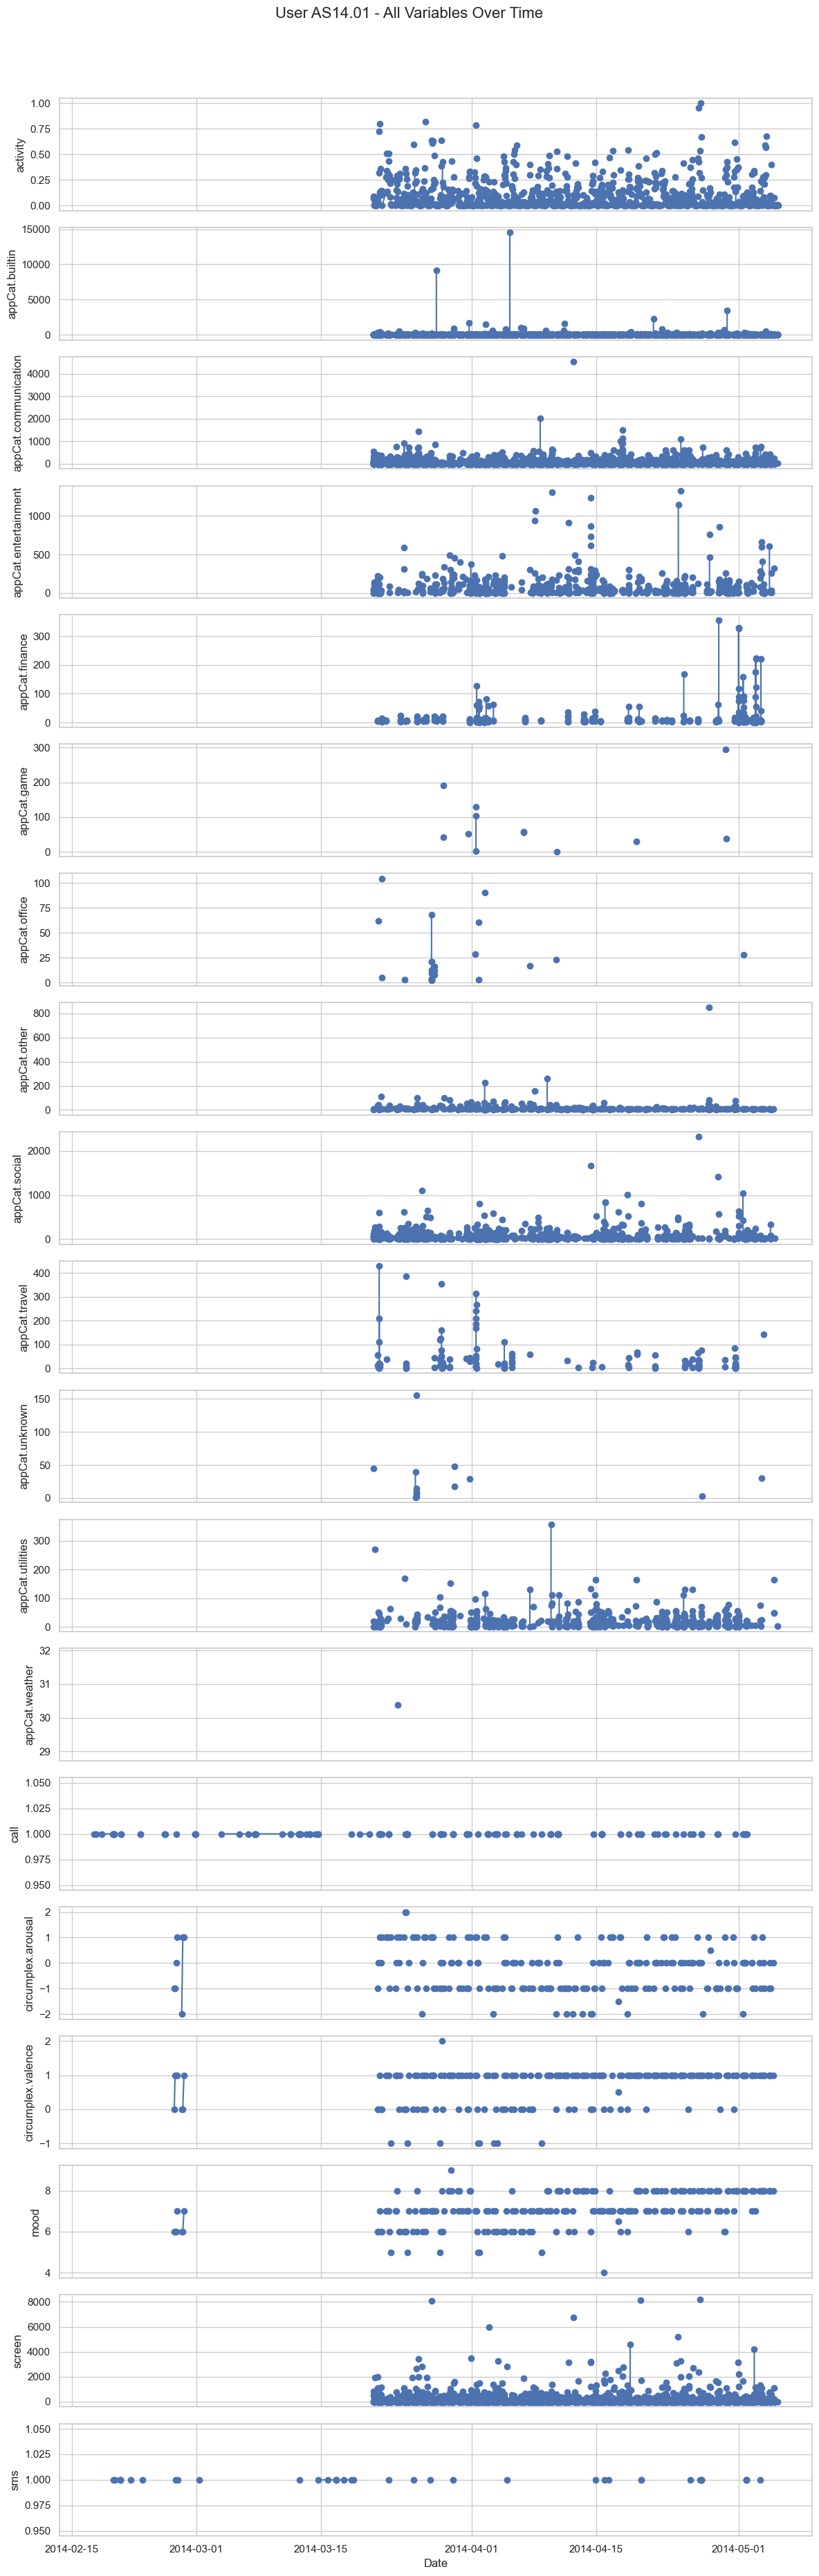

In [112]:
person_ids = df["id"].unique()[:1]  # eerste 3 personen

for person_id in person_ids:
    df_person = df[df["id"] == person_id]

    # Pivot naar wide format
    df_pivot = df_person.pivot_table(
        index="time",
        columns="variable",
        values="value"
    ).sort_index()

    # Dagelijks gemiddelde
    # df_pivot = df_pivot.resample("D").mean()

    variables = df_pivot.columns
    n_vars = len(variables)

    # Eén figuur per persoon
    fig, axes = plt.subplots(n_vars, 1, figsize=(12, 2*n_vars), sharex=True)

    if n_vars == 1:
        axes = [axes]  # voor 1 variabele

    for i, var in enumerate(variables):
        axes[i].plot(df_pivot.index, df_pivot[var], marker='o')
        axes[i].set_ylabel(var)
        axes[i].grid(True)

    fig.suptitle(f"User {person_id} - All Variables Over Time", fontsize=16)
    plt.xlabel("Date")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [115]:
df["hour"] = df["time"].dt.strftime("%H:%M")
for var in df["variable"].unique():
    hours = df[df["variable"] == var]["hour"].unique()
    print(f"{var}:{len(hours)}")

mood:22
circumplex.arousal:22
circumplex.valence:22
activity:24
screen:1440
call:1042
sms:837
appCat.builtin:1436
appCat.communication:1429
appCat.entertainment:1291
appCat.finance:414
appCat.game:529
appCat.office:1148
appCat.other:1010
appCat.social:1323
appCat.travel:988
appCat.unknown:568
appCat.utilities:975
appCat.weather:203


Sommige zijn waarschijnlijk per occurence, want ze vinden op veel verschillende tijdstippen plaats, waar bijvoorbeeld mood uurlijks is

# Call + SMS


--- User AS14.01 ---
Time range: 2014-02-17 12:04:42.394000 - 2014-05-05 10:00:00
Total records: 21999
Variables recorded: 19


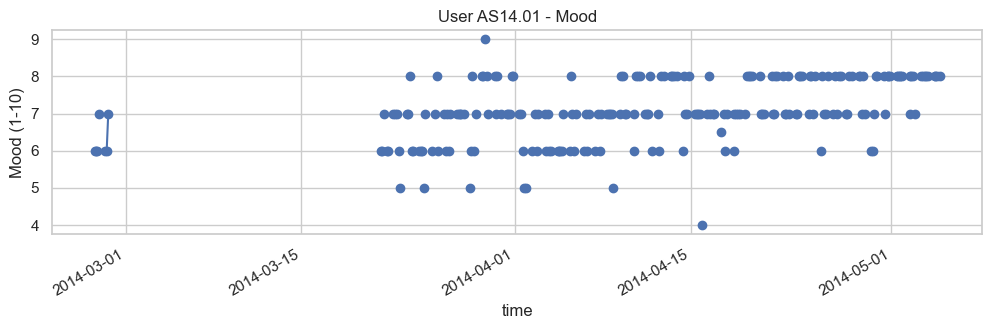

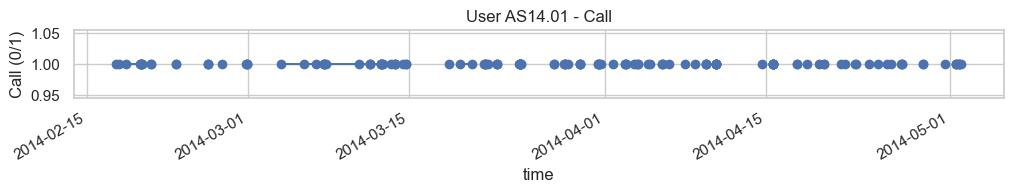

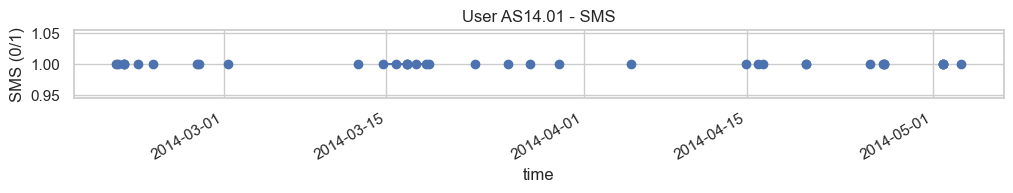

In [82]:

# Kies personen
person_ids = df["id"].unique()[:1]  # eerste 3 personen, kan je uitbreiden

for person_id in person_ids:
    print(f"\n--- User {person_id} ---")
    df_person = df[df["id"] == person_id]

    # Info printen
    print(f"Time range: {df_person['time'].min()} - {df_person['time'].max()}")
    print(f"Total records: {len(df_person)}")
    print(f"Variables recorded: {df_person['variable'].nunique()}")

    # Pivot naar wide format
    df_pivot = df_person.pivot_table(
        index="time",
        columns="variable",
        values="value"
    ).sort_index()

    # --- Mood plot ---
    if "mood" in df_pivot.columns:
        df_pivot["mood"].plot(figsize=(12,3), marker='o', title=f"User {person_id} - Mood")
        plt.ylabel("Mood (1-10)")
        plt.grid(True)
        plt.show()

    # --- Call plot ---
    if "call" in df_pivot.columns:
        df_pivot["call"].plot(figsize=(12,1), marker='o', title=f"User {person_id} - Call")
        plt.ylabel("Call (0/1)")
        plt.grid(True)
        plt.show()

    # --- SMS plot ---
    if "sms" in df_pivot.columns:
        df_pivot["sms"].plot(figsize=(12,1), marker='o', title=f"User {person_id} - SMS")
        plt.ylabel("SMS (0/1)")
        plt.grid(True)
        plt.show()

Call en SMS beginnen eerder dan de mood en de rest, geld ook voor de andere patienten

In [ ]:

# Kies variabele om te plotten
variable_to_plot = "mood"  # bijvoorbeeld "mood", "activity", "call", etc.

# Unieke personen
person_ids = df["id"].unique()

for person_id in person_ids:
    df_person = df[df["id"] == person_id]
    
    # Pivot naar wide format
    df_pivot = df_person.pivot_table(
        index="time",
        columns="variable",
        values="value"
    ).sort_index()

    print(df_person[df_person['variable']=='mood']['time'].min())

2014-02-26 13:00:00
2014-03-16 15:00:00
2014-03-21 18:00:00
2014-03-14 12:00:00
2014-03-24 21:00:00
2014-03-19 11:00:00
2014-03-05 15:00:00
2014-03-21 21:00:00
2014-03-15 13:00:00
2014-03-13 21:00:00
2014-03-20 15:00:00
2014-03-14 12:00:00
2014-03-13 18:00:00
2014-03-04 18:00:00
2014-03-21 15:00:00
2014-03-20 21:00:00
2014-03-22 18:00:00
2014-04-14 21:00:00
2014-04-08 17:00:00
2014-03-23 17:00:00
2014-04-03 09:00:00
2014-03-31 18:00:00
2014-04-02 12:00:00
2014-03-20 15:00:00
2014-04-02 12:00:00
2014-04-01 18:00:00
2014-04-16 15:00:00


Mood begint per persoon op een andere datum

# Summary ai

In [ ]:
# Summary statistics per variable
summary = df.groupby("variable")["value"].agg(
    count="count",
    missing=lambda x: x.isna().sum(),
    missing_pct=lambda x: round(100 * x.isna().mean(), 2),
    mean="mean",
    std="std",
    median="median",
    min="min",
    max="max",
).reset_index()

summary["type"] = summary["variable"].apply(
    lambda v: "ordinal (1-10)" if v == "mood"
    else "continuous (-2 to 2)" if "circumplex" in v
    else "binary" if v in ["call", "sms"]
    else "continuous (0-1)" if v == "activity"
    else "continuous (duration)" if v == "screen" or "appCat" in v
    else "unknown"
)

summary = summary[["variable", "type", "count", "missing", "missing_pct", "min", "max", "mean", "median", "std"]]
summary.round(3)

,variable,type,count,missing,missing_pct,min,max,mean,median,std
0,activity,continuous (0-1),22965,0,0.00,0.000,1.000,0.116,0.022,0.187
1,appCat.builtin,continuous (duration),91288,0,0.00,-82798.871,33960.246,18.538,4.038,415.989
2,appCat.communication,continuous (duration),74276,0,0.00,0.006,9830.777,43.344,16.226,128.913
3,appCat.entertainment,continuous (duration),27125,0,0.00,-0.011,32148.677,37.576,3.391,262.960
4,appCat.finance,continuous (duration),939,0,0.00,0.131,355.513,21.755,8.026,39.218
5,appCat.game,continuous (duration),813,0,0.00,1.003,5491.793,128.392,43.168,327.145
6,appCat.office,continuous (duration),5642,0,0.00,0.003,32708.818,22.579,3.106,449.601
7,appCat.other,continuous (duration),7650,0,0.00,0.014,3892.038,25.811,10.028,112.781
8,appCat.social,continuous (duration),19145,0,0.00,0.094,30000.906,72.402,28.466,261.552
9,appCat.travel,continuous (duration),2846,0,0.00,0.080,10452.615,45.731,18.144,246.109


Weinig na waardes

Hoe kunnen sommige scherm tijdend negatief beginnen? zoals appCat.builtin

# Missing values (not na)
Hourly variables: activity, mood, arousal, valence

In [97]:
df["hour"] = df["time"].dt.strftime("%H:%M")
for var in ['mood', 'activity', 'circumplex.arousal', 'circumplex.valence']:
    hours = df[df["variable"] == var]["hour"].unique()
    hours = sorted(hours)
    print(f"{var}:{len(hours)}, {hours}")

mood:22, ['00:00', '01:00', '02:00', '03:00', '04:00', '07:00', '08:00', '09:00', '10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00', '17:00', '18:00', '19:00', '20:00', '21:00', '22:00', '23:00']
activity:24, ['00:00', '01:00', '02:00', '03:00', '04:00', '05:00', '06:00', '07:00', '08:00', '09:00', '10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00', '17:00', '18:00', '19:00', '20:00', '21:00', '22:00', '23:00']
circumplex.arousal:22, ['00:00', '01:00', '02:00', '03:00', '04:00', '07:00', '08:00', '09:00', '10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00', '17:00', '18:00', '19:00', '20:00', '21:00', '22:00', '23:00']
circumplex.valence:22, ['00:00', '01:00', '02:00', '03:00', '04:00', '07:00', '08:00', '09:00', '10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00', '17:00', '18:00', '19:00', '20:00', '21:00', '22:00', '23:00']


De  waardes van mood, valence en arousel lijk op dezelfde plek te zitten en alleen tijdens wakkere uren. Mogelijk de missende waardes opdezelfde plek


Activity is de hele dag door


--- User AS14.01 ---


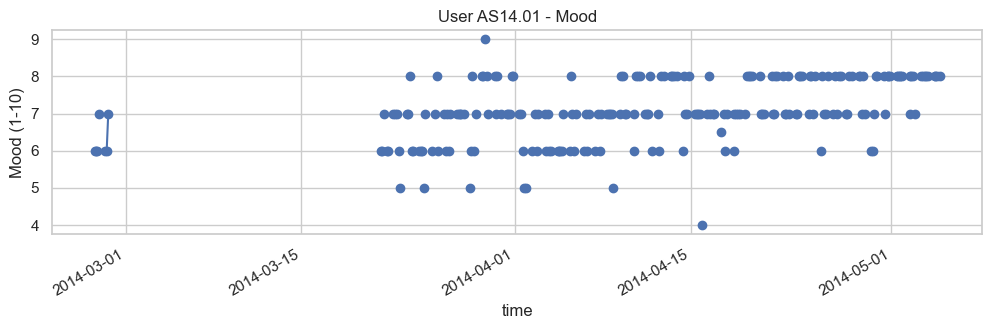

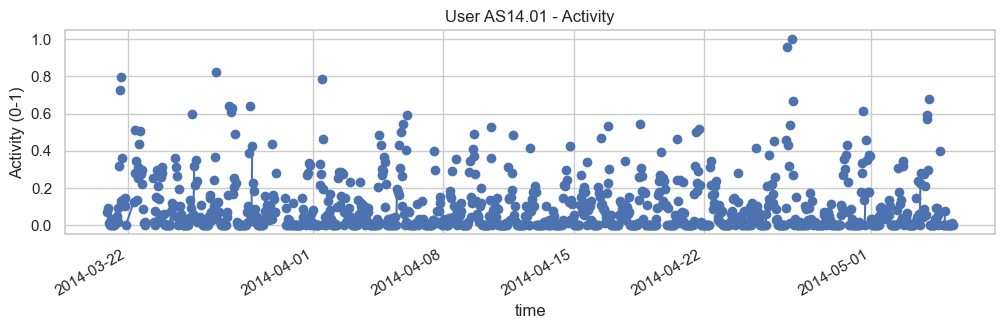

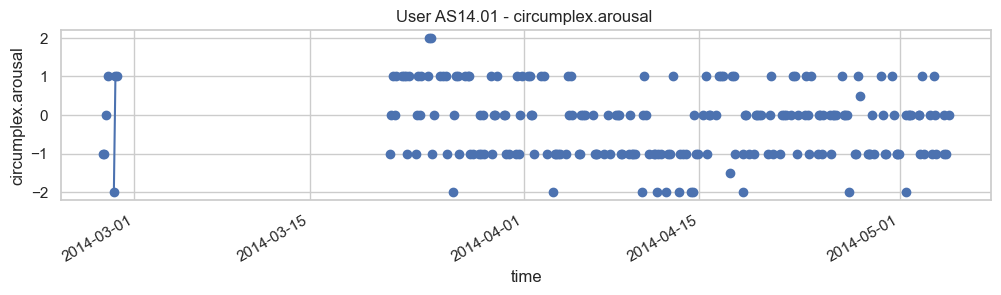

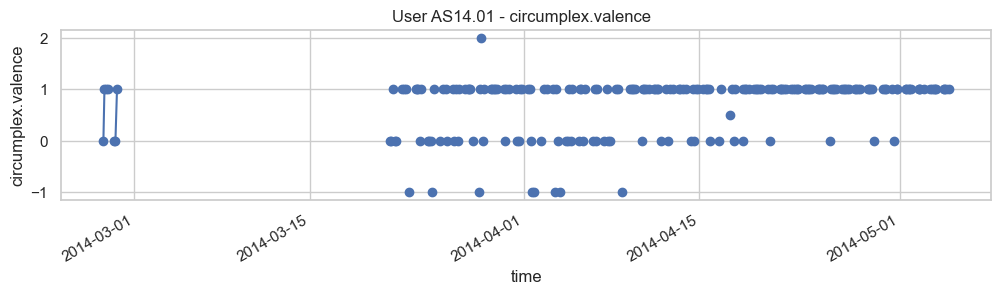

In [98]:
# Kies personen
person_ids = df["id"].unique()[:1]  # eerste 3 personen, kan je uitbreiden

for person_id in person_ids:
    print(f"\n--- User {person_id} ---")
    df_person = df[df["id"] == person_id]

    # # Info printen
    # print(f"Time range: {df_person['time'].min()} - {df_person['time'].max()}")
    # print(f"Total records: {len(df_person)}")
    # print(f"Variables recorded: {df_person['variable'].nunique()}")

    # Pivot naar wide format
    df_pivot = df_person.pivot_table(
        index="time",
        columns="variable",
        values="value"
    ).sort_index()

    # --- Mood plot ---
    if "mood" in df_pivot.columns:
        df_pivot["mood"].plot(figsize=(12,3), marker='o', title=f"User {person_id} - Mood")
        plt.ylabel("Mood (1-10)")
        plt.grid(True)
        plt.show()

    # --- Activity plot ---
    if "activity" in df_pivot.columns:
        df_pivot["activity"].plot(figsize=(12,3), marker='o', title=f"User {person_id} - Activity")
        plt.ylabel("Activity (0-1)")
        plt.grid(True)
        plt.show()

    if "circumplex.arousal" in df_pivot.columns:
        df_pivot["circumplex.arousal"].plot(figsize=(12,2.5), marker='o', title=f"User {person_id} - circumplex.arousal ")
        plt.ylabel("circumplex.arousal")
        plt.grid(True)
        plt.show()
    
    if "circumplex.valence" in df_pivot.columns:
        df_pivot["circumplex.valence"].plot(figsize=(12,2.5), marker='o', title=f"User {person_id} - circumplex.valence  ")
        plt.ylabel("circumplex.valence")
        plt.grid(True)
        plt.show()

In [99]:
hourly_vars = ["mood", "circumplex.arousal", "circumplex.valence"]

for user_id in df["id"].unique():
    awake_times = {}
    for var in hourly_vars:
        # Selecteer data van deze variabele en persoon
        df_var = df[(df["id"] == user_id) & (df["variable"] == var)]
        # Unieke datetime-momenten
        awake_times[var] = sorted(df_var["time"].unique())
    
    # Check of alle datetime-momenten gelijk zijn
    all_equal = all(awake_times[var] == awake_times[hourly_vars[0]] for var in hourly_vars[1:])
    
    if not all_equal:
        print(f"User {user_id}:")
        for var, times in awake_times.items():
            print(f"  {var}: {times}")
        print(f"  Awake times equal across variables? {all_equal}\n")

De missende waardes van mood etc. zitten inderdaad op dezelfde plek.

Nu de missende waardes van activity op basis van de eerste datum mood meting tot de laatste mood meting

In [136]:
# Kies de hourly variabelen
hourly_vars = ["activity"]

# Alle gebruikers
user_ids = df["id"].unique()
total_missing_count = 0
total_posible = 0

for user_id in user_ids:
    # print(f"\n--- User {user_id} ---")
    
    # Basis tijdrange van mood
    df_mood = df[(df["id"] == user_id) & (df["variable"] == "mood")].set_index("time").sort_index()
    if df_mood.empty:
        print("No mood data for this user, skipping.")
        continue
    
    start = df_mood.index.min().floor('h')
    end = df_mood.index.max().ceil('h')
    hourly_index = pd.date_range(start=start, end=end, freq="h")
    
    # print(f"Time range based on mood: {start_time} - {end_time} ({len(hourly_index)} hours)")
    
    # Check per hourly variable
    for var in hourly_vars:
        df_var = df[(df["id"] == user_id) & (df["variable"] == var)].set_index("time").sort_index()
        
        # Reindex naar de mood-hourly index
        df_var_hourly = df_var.reindex(hourly_index)
        
        missing_count = df_var_hourly["value"].isna().sum()
        missing_pct = 100 * missing_count / len(hourly_index)
        total_missing_count += missing_count
        total_posible += len(hourly_index)
        
        print(f"{user_id}, {var}: {missing_count} missing hours ({missing_pct:.2f}%)")

print(f"Total: {total_missing_count} missing hours ({total_missing_count/total_posible:.2f}%)")    

AS14.01, activity: 574 missing hours (35.50%)
AS14.02, activity: 280 missing hours (28.96%)
AS14.03, activity: 18 missing hours (1.59%)
AS14.05, activity: 83 missing hours (6.63%)
AS14.06, activity: 300 missing hours (28.06%)
AS14.07, activity: 186 missing hours (16.34%)
AS14.08, activity: 306 missing hours (20.89%)
AS14.09, activity: 413 missing hours (38.53%)
AS14.12, activity: 298 missing hours (24.23%)
AS14.13, activity: 686 missing hours (55.77%)
AS14.14, activity: 128 missing hours (11.58%)
AS14.15, activity: 1130 missing hours (85.54%)
AS14.16, activity: 827 missing hours (65.12%)
AS14.17, activity: 409 missing hours (27.52%)
AS14.19, activity: 16 missing hours (1.48%)
AS14.20, activity: 810 missing hours (73.84%)
AS14.23, activity: 351 missing hours (37.82%)
AS14.24, activity: 11 missing hours (0.84%)
AS14.25, activity: 76 missing hours (10.58%)
AS14.26, activity: 556 missing hours (33.96%)
AS14.27, activity: 24 missing hours (2.37%)
AS14.28, activity: 69 missing hours (7.62%)


Sommige missen best wel veel, andere bijna niets

AS14.01


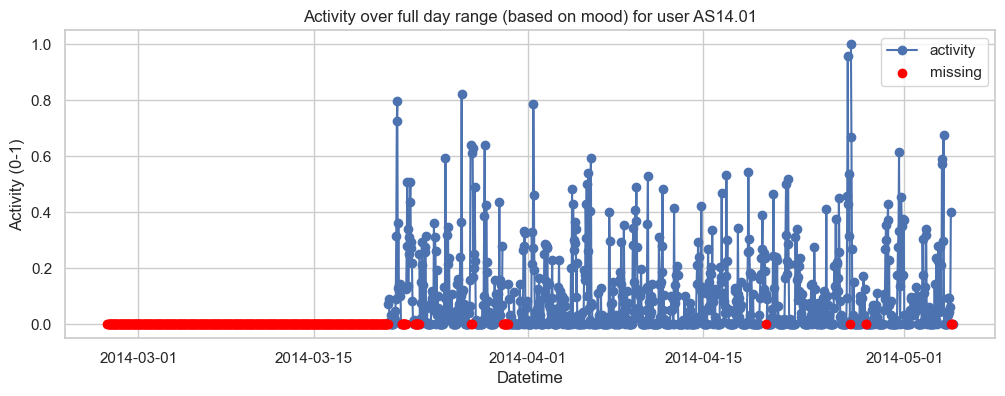

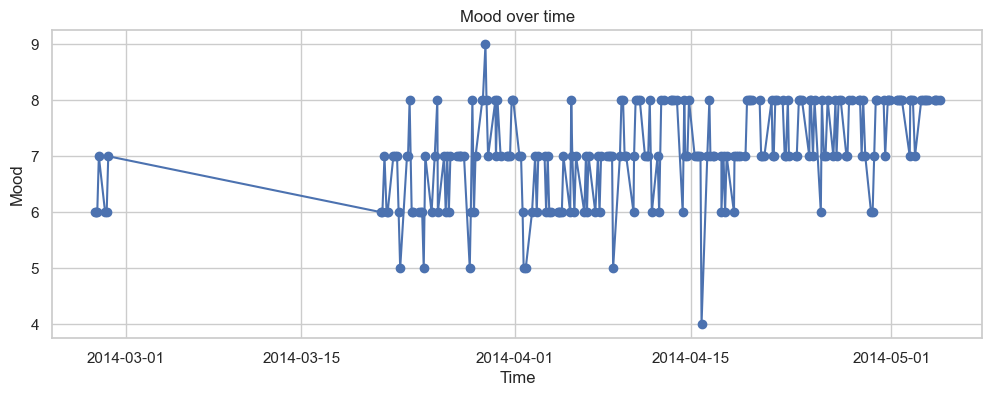

AS14.15


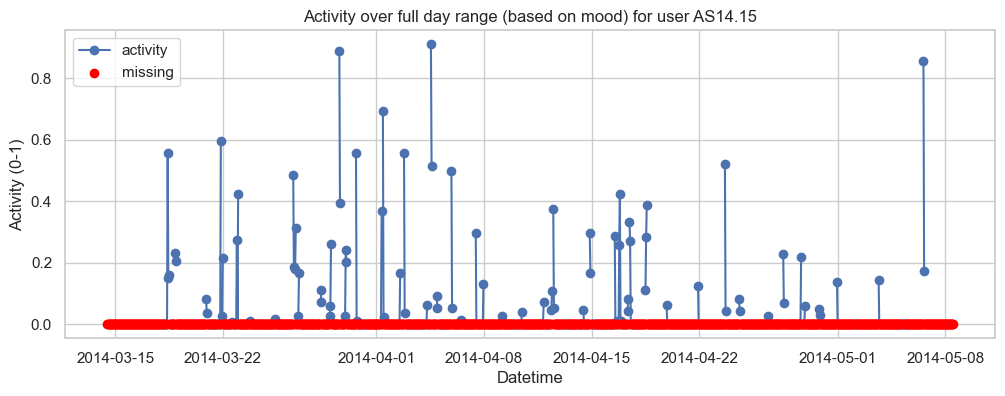

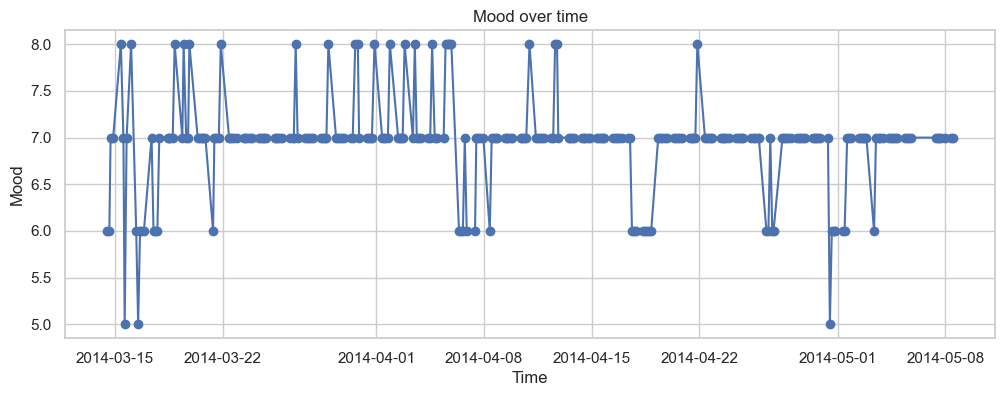

In [111]:
# plot voor missende waardes
var = "activity"

for user_id in list(df["id"].unique()[:1])+ ['AS14.15']:
    print(user_id)
    # Data van deze persoon
    df_person = df[(df["id"] == user_id) & (df["variable"] == var)].copy()

    # Basis: mood-data van deze persoon
    df_mood = df[(df["id"] == user_id) & (df["variable"] == "mood")].copy()
    df_user = df[df["id"] == user_id].copy()

    start = df_mood["time"].min().floor('h')
    end = df_mood["time"].max().ceil('h')
    full_index = pd.date_range(start=start, end=end, freq='h')  # elk uur
    
    # Reindex activity naar dit volledige index
    df_person.set_index("time", inplace=True)
    df_person = df_person.reindex(full_index)
    
    plt.figure(figsize=(12,4))
    
    # Activity plot
    plt.plot(df_person.index, df_person["value"], marker='o', linestyle='-', label='activity')
    
    # Missing hours highlight
    missing = df_person[df_person["value"].isna()]
    if not missing.empty:
        plt.scatter(missing.index, [0]*len(missing), color='red', label='missing', zorder=5)

    plt.title(f"Activity over full day range (based on mood) for user {user_id}")
    plt.xlabel("Datetime")
    plt.ylabel("Activity (0-1)")
    if not missing.empty:
        plt.legend()
    plt.show()

    plt.figure(figsize=(12,4))
    plt.plot(df_mood["time"], df_mood["value"], marker="o")
    plt.title("Mood over time")
    plt.xlabel("Time")
    plt.ylabel("Mood")
    plt.grid(True)
    plt.show()

In [141]:
mood_dupes = (
    df[df["variable"] == "mood"]
    .groupby("id")["time"]
    .apply(lambda x: x.duplicated().sum())
)

print(mood_dupes[mood_dupes > 0])

df_mood_all = df[df["variable"] == "mood"]

dupes = df_mood_all[df_mood_all.duplicated(subset=["id", "time"], keep=False)]

print(dupes.sort_values(["id", "time"]))

id
AS14.01    1
AS14.02    2
AS14.06    1
AS14.12    2
AS14.16    1
AS14.17    1
AS14.25    2
AS14.28    2
AS14.33    1
Name: time, dtype: int64
           id                time variable  value
136   AS14.01 2014-04-17 11:00:00     mood    7.0
137   AS14.01 2014-04-17 11:00:00     mood    6.0
359   AS14.02 2014-04-17 18:00:00     mood    6.0
360   AS14.02 2014-04-17 18:00:00     mood    7.0
372   AS14.02 2014-04-21 20:00:00     mood    5.0
373   AS14.02 2014-04-21 20:00:00     mood    6.0
938   AS14.06 2014-04-13 17:00:00     mood    7.0
939   AS14.06 2014-04-13 17:00:00     mood    5.0
1749  AS14.12 2014-03-30 11:00:00     mood    6.0
1750  AS14.12 2014-03-30 11:00:00     mood    7.0
1874  AS14.12 2014-04-25 17:00:00     mood    4.0
1875  AS14.12 2014-04-25 17:00:00     mood    5.0
2670  AS14.16 2014-03-29 20:00:00     mood    7.0
2671  AS14.16 2014-03-29 20:00:00     mood    6.0
3061  AS14.17 2014-05-03 17:00:00     mood    7.0
3062  AS14.17 2014-05-03 17:00:00     mood    8.0
3967 

Er zitten dubbele moods in de dataset

In [150]:
import pandas as pd

hourly_vars = ["mood"]

user_ids = df["id"].unique()

total_missing_count = 0
total_possible = 0

for user_id in user_ids:
    
    # -----------------------------
    # mood data
    # -----------------------------
    df_mood = df[(df["id"] == user_id) & (df["variable"] == "mood")].copy()
    
    if df_mood.empty:
        print(f"{user_id}: No mood data")
        continue
    
    df_mood["time"] = pd.to_datetime(df_mood["time"])
    df_mood = df_mood.set_index("time").sort_index()
    
    # -----------------------------
    # awake window (ONLY where mood exists)
    # -----------------------------
    start = df_mood.index.min().floor("h")
    end = df_mood.index.max().ceil("h")
    awake_index = pd.date_range(start=start, end=end, freq="h")
    
    # print(f"\n--- User {user_id} ---")
    # print(f"Awake window hours: {len(awake_index)}")
    
    # -----------------------------
    # fix duplicates + align mood
    # -----------------------------
    mood_hourly = df_mood.groupby(df_mood.index)["value"].mean()
    mood_hourly = mood_hourly.reindex(awake_index)
    
    # -----------------------------
    # missing calculation
    # -----------------------------
    missing_count = mood_hourly.isna().sum()
    missing_pct = 100 * missing_count / len(awake_index)
    
    total_missing_count += missing_count
    total_possible += len(awake_index)
    
    print(f"{user_id}, mood: {missing_count} missing hours ({missing_pct:.2f}%)")

# -----------------------------
# total summary
# -----------------------------
print("\n===== TOTAL =====")
print(f"Missing hours: {total_missing_count}")
print(f"Missing %: {100 * total_missing_count / total_possible:.2f}%")

AS14.01, mood: 1396 missing hours (86.33%)
AS14.02, mood: 810 missing hours (83.76%)
AS14.03, mood: 911 missing hours (80.48%)
AS14.05, mood: 1011 missing hours (80.75%)
AS14.06, mood: 867 missing hours (81.10%)
AS14.07, mood: 946 missing hours (83.13%)
AS14.08, mood: 1166 missing hours (79.59%)
AS14.09, mood: 875 missing hours (81.62%)
AS14.12, mood: 1047 missing hours (85.12%)
AS14.13, mood: 986 missing hours (80.16%)
AS14.14, mood: 941 missing hours (85.16%)
AS14.15, mood: 1052 missing hours (79.64%)
AS14.16, mood: 1040 missing hours (81.89%)
AS14.17, mood: 1250 missing hours (84.12%)
AS14.19, mood: 863 missing hours (79.61%)
AS14.20, mood: 895 missing hours (81.59%)
AS14.23, mood: 769 missing hours (82.87%)
AS14.24, mood: 1071 missing hours (81.82%)
AS14.25, mood: 589 missing hours (82.03%)
AS14.26, mood: 1308 missing hours (79.90%)
AS14.27, mood: 813 missing hours (80.34%)
AS14.28, mood: 739 missing hours (81.57%)
AS14.29, mood: 846 missing hours (81.90%)
AS14.30, mood: 881 missin

Veel missende moods data, maar dit klopt nog niet helemaal wat dit is 24/7 en niet de wakkere uren

In [156]:
import pandas as pd

user_ids = df["id"].unique()

for user_id in user_ids:
    
    # -----------------------------
    # mood data
    # -----------------------------
    df_mood = df[(df["id"] == user_id) & (df["variable"] == "mood")].copy()
    
    if df_mood.empty:
        print(f"{user_id}: No mood data")
        continue
    
    df_mood["time"] = pd.to_datetime(df_mood["time"])
    df_mood["date"] = df_mood["time"].dt.date
    
    # -----------------------------
    # all possible days in patient range
    # -----------------------------
    start_day = df_mood["time"].min().floor("D")
    end_day = df_mood["time"].max().floor("D")
    
    all_days = pd.date_range(start=start_day, end=end_day, freq="D").date
    
    # -----------------------------
    # days WITH at least 1 measurement
    # -----------------------------
    observed_days = df_mood["date"].unique()
    
    # -----------------------------
    # missing days
    # -----------------------------
    missing_days = set(all_days) - set(observed_days)
    
    missing_count = len(missing_days)
    total_days = len(all_days)
    
    missing_pct = 100 * missing_count / total_days
    
    print(f"{user_id}: {missing_count} missing days out of {total_days} ({missing_pct:.2f}%)")

AS14.01: 21 missing days out of 68 (30.88%)
AS14.02: 0 missing days out of 41 (0.00%)
AS14.03: 1 missing days out of 48 (2.08%)
AS14.05: 0 missing days out of 53 (0.00%)
AS14.06: 1 missing days out of 46 (2.17%)
AS14.07: 0 missing days out of 48 (0.00%)
AS14.08: 0 missing days out of 62 (0.00%)
AS14.09: 0 missing days out of 46 (0.00%)
AS14.12: 11 missing days out of 52 (21.15%)
AS14.13: 0 missing days out of 53 (0.00%)
AS14.14: 3 missing days out of 47 (6.38%)
AS14.15: 1 missing days out of 56 (1.79%)
AS14.16: 1 missing days out of 54 (1.85%)
AS14.17: 7 missing days out of 63 (11.11%)
AS14.19: 0 missing days out of 46 (0.00%)
AS14.20: 0 missing days out of 47 (0.00%)
AS14.23: 1 missing days out of 40 (2.50%)
AS14.24: 1 missing days out of 56 (1.79%)
AS14.25: 1 missing days out of 31 (3.23%)
AS14.26: 1 missing days out of 69 (1.45%)
AS14.27: 1 missing days out of 43 (2.33%)
AS14.28: 1 missing days out of 39 (2.56%)
AS14.29: 2 missing days out of 44 (4.55%)
AS14.30: 0 missing days out o

Dit is mogelijk beter, het aantal dagen dat er geen mood is gemeten

# Continue variabelen


--- User AS14.01 ---
Total records: 21999
Variables recorded: 19


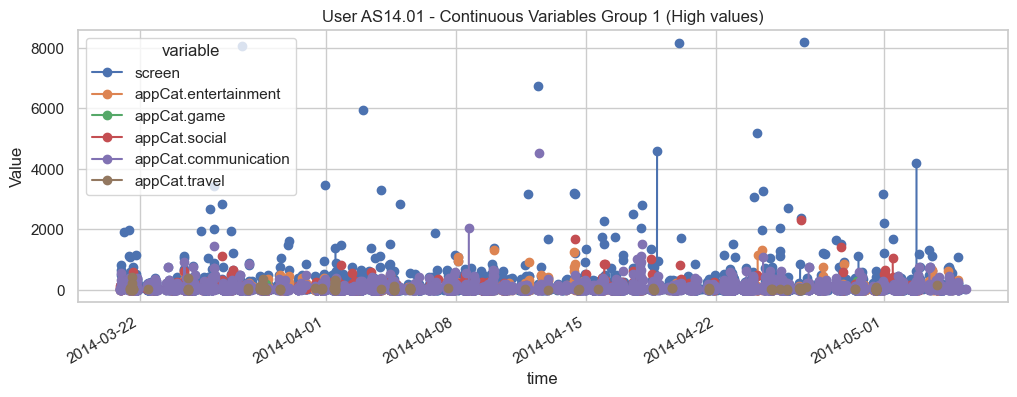

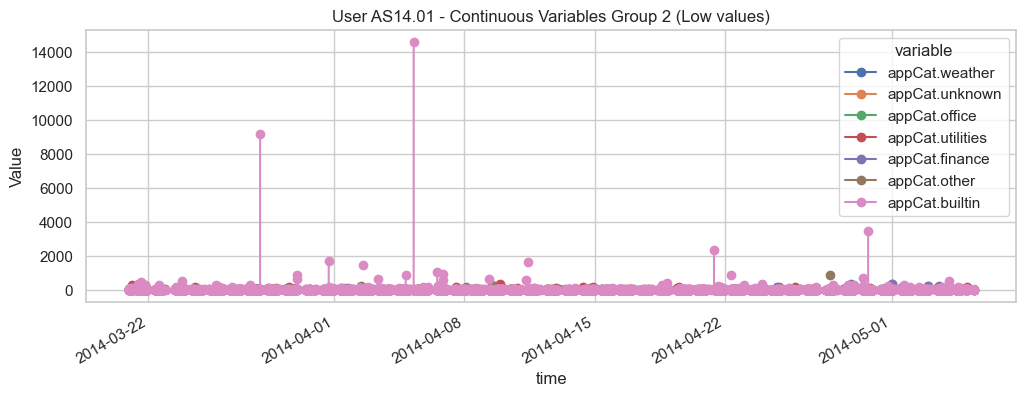


--- User AS14.02 ---
Total records: 14581
Variables recorded: 14


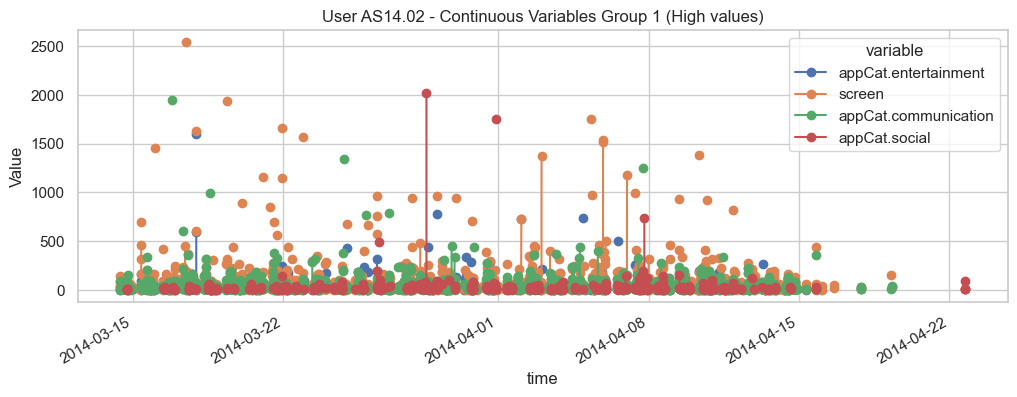

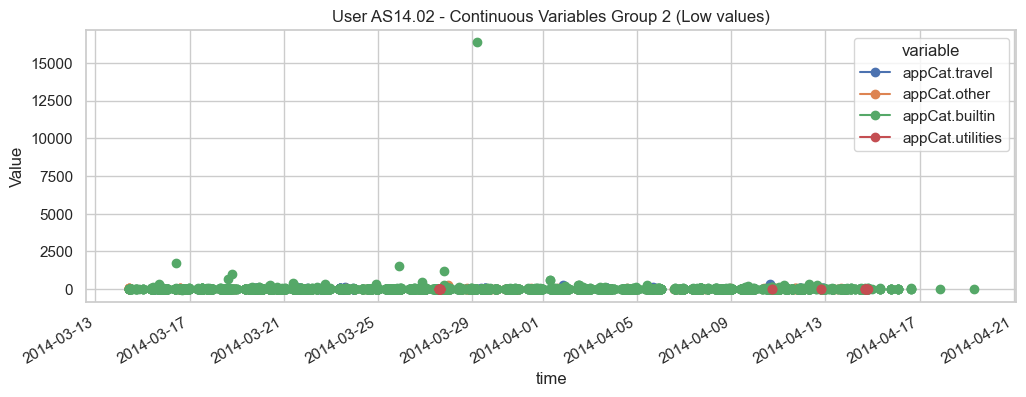

In [127]:
# Kies personen
person_ids = df["id"].unique()[:2]  # eerste 3 personen, kan je uitbreiden

for person_id in person_ids:
    print(f"\n--- User {person_id} ---")
    df_person = df[df["id"] == person_id]

    # Info printen
    # print(f"Time range: {df_person['time'].min()} - {df_person['time'].max()}")
    print(f"Total records: {len(df_person)}")
    print(f"Variables recorded: {df_person['variable'].nunique()}")

    # Pivot naar wide format
    df_pivot = df_person.pivot_table(
        index="time",
        columns="variable",
        values="value"
    ).sort_index()

    # --- Continue variabelen excluding mood, call, sms ---
    continuous_vars = [v for v in df_pivot.columns if v not in ["mood","call","sms", "activity", "circumplex.valence", "circumplex.arousal" ]]

    if continuous_vars:
        # Sorteer op maximale waarde
        max_values = df_pivot[continuous_vars].mean().sort_values(ascending=False)
        sorted_vars = list(max_values.index)

        # Splits in 2 groepen op basis van max waarde
        mid = len(sorted_vars)//2
        group1 = sorted_vars[:mid]  # hoge maxima
        group2 = sorted_vars[mid:]  # lage maxima

        if group1:
            df_pivot[group1].plot(figsize=(12,4), marker='o', title=f"User {person_id} - Continuous Variables Group 1 (High values)")
            plt.ylabel("Value")
            plt.grid(True)
            plt.show()

        if group2:
            df_pivot[group2].plot(figsize=(12,4), marker='o', title=f"User {person_id} - Continuous Variables Group 2 (Low values)")
            plt.ylabel("Value")
            plt.grid(True)
            plt.show()

Niet echt direct iets uit te halen. Deze variabelen vinden plaats bij occurence dus geen missende waarden

# Proberen/ zooi / oude code

In [131]:

# # Variabelen waarvoor we dit willen checken 
# variables_to_check = [v for v in df["variable"].unique() if v != "sms" and  v != "call" and v[:3] != "app"]

# # Uniek overzicht per persoon
# daily_presence = {}

# for user_id in df["id"].unique():
#     df_person = df[df["id"] == user_id]
#     daily_presence[user_id] = {}
    
#     for var in variables_to_check:
#         df_var = df_person[df_person["variable"] == var].copy()
#         df_var['date'] = df_var['time'].dt.date  # alleen datum
#         unique_days = df_var['date'].nunique()
#         daily_presence[user_id][var] = unique_days

# # Omzetten naar DataFrame
# daily_presence_df = pd.DataFrame(daily_presence).T  # personen als rijen

# # Alleen rijen tonen waar de waarden **niet allemaal gelijk zijn**
# unequal_rows = daily_presence_df[daily_presence_df.nunique(axis=1) > 1]

# print(unequal_rows)

In [130]:
# #plot 1 variable of multible patients


# # Kies variabele om te plotten
# variable_to_plot = "mood"  # bijvoorbeeld "mood", "activity", "call", etc.

# # Unieke personen
# person_ids = df["id"].unique()

# for person_id in person_ids:
#     df_person = df[df["id"] == person_id]
    
#     # Pivot naar wide format
#     df_pivot = df_person.pivot_table(
#         index="time",
#         columns="variable",
#         values="value"
#     ).sort_index()

#     print(df_person[df_person['variable']=='mood']['time'].min())

#     # Dagelijks gemiddelde
#     # df_pivot = df_pivot.resample("D").mean()

#     # if variable_to_plot in df_pivot.columns:
#     #     plt.figure(figsize=(12,4))
#     #     plt.plot(df_pivot.index, df_pivot[variable_to_plot], marker='o')
#     #     plt.title(f"User {person_id} - {variable_to_plot.capitalize()} over time")
#     #     plt.xlabel("Time")
#     #     plt.ylabel(variable_to_plot.capitalize())
#     #     plt.grid(True)
#     #     plt.show()